# Telco churn — logistic regression + EDA

Daily notebook — small experiment, fully reproducible (seed pinned below).

New dataset: synthetic telco churn. Baseline first, look at coefficients.

## Setup

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.model_selection import learning_curve, validation_curve
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge, Lasso
from sklearn.ensemble import (RandomForestClassifier, RandomForestRegressor,
                              GradientBoostingClassifier, GradientBoostingRegressor,
                              HistGradientBoostingClassifier, VotingClassifier,
                              IsolationForest)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (accuracy_score, roc_auc_score, confusion_matrix,
                             classification_report, mean_squared_error,
                             mean_absolute_error, r2_score, silhouette_score)


## Data

In [ ]:
SEED = 1016

rng = np.random.RandomState(SEED)
n = 2500
tenure = rng.randint(0, 72, size=n)
monthly = np.clip(rng.normal(70, 25, size=n), 20, 150).round(2)
contract = rng.choice(["month-to-month", "one year", "two year"], size=n, p=[0.55, 0.25, 0.20])
internet = rng.choice(["DSL", "Fiber optic", "No"], size=n, p=[0.35, 0.45, 0.20])
support = rng.choice(["Yes", "No"], size=n, p=[0.35, 0.65])
logit = (-1.2 + 0.9 * (contract == "month-to-month") + 0.012 * monthly
         - 0.03 * tenure + 0.5 * (internet == "Fiber optic") - 0.4 * (support == "Yes"))
churn = (rng.rand(n) < 1 / (1 + np.exp(-logit))).astype(int)
df = pd.DataFrame({"tenure": tenure, "MonthlyCharges": monthly, "Contract": contract,
                   "InternetService": internet, "TechSupport": support, "Churn": churn})
print("shape:", df.shape)
print(df.head(3).to_string())
print("\nchurn rate: %.3f" % df["Churn"].mean())


shape: (2500, 6)
   tenure  MonthlyCharges        Contract InternetService TechSupport  Churn
0      52           81.72  month-to-month     Fiber optic          No      0
1       1           83.79  month-to-month     Fiber optic          No      1
2      64          103.17        one year              No          No      0

churn rate: 0.336


## Churn by contract type

Contract
two year          0.249
one year          0.255
month-to-month    0.402


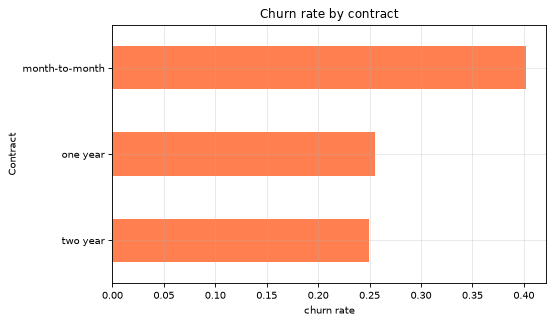

In [ ]:

ct = df.groupby("Contract")["Churn"].mean().sort_values()
fig, ax = plt.subplots()
ct.plot.barh(ax=ax, color="coral")
ax.set_xlabel("churn rate"); ax.set_title("Churn rate by contract")
print(ct.round(3).to_string())


## Model

In [ ]:
num_features = ['tenure', 'MonthlyCharges']
cat_features = ['Contract', 'InternetService', 'TechSupport']
preprocess = ColumnTransformer([
    ("num", Pipeline([("imputer", SimpleImputer(strategy="median")),
                      ("scaler", StandardScaler())]), num_features),
    ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
                      ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]), cat_features),
])

X = df.drop(columns=["Churn"]); y = df["Churn"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y)
clf = Pipeline([("prep", preprocess),
                ("model", LogisticRegression(max_iter=1000))])
clf.fit(X_train, y_train)
pred = clf.predict(X_test)
print(f"accuracy: {accuracy_score(y_test, pred):.4f}")
print(f"roc auc: {roc_auc_score(y_test, clf.predict_proba(X_test)[:, 1]):.4f}")
print(classification_report(y_test, pred, digits=3))


accuracy: 0.7060
roc auc: 0.7000
              precision    recall  f1-score   support

           0      0.731     0.883     0.799       332
           1      0.606     0.357     0.449       168

    accuracy                          0.706       500
   macro avg      0.668     0.620     0.624       500
weighted avg      0.689     0.706     0.682       500



## Coefficients

largest |coef|: num__tenure


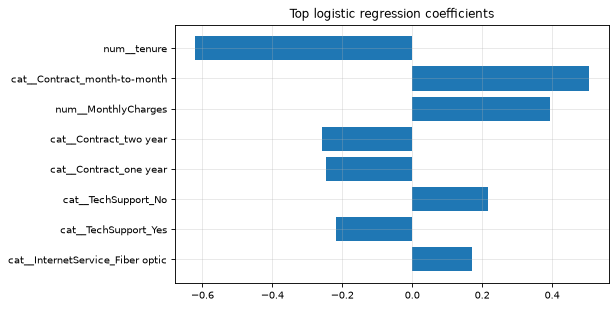

In [ ]:

coefs = clf.named_steps["model"].coef_[0]
names = clf.named_steps["prep"].get_feature_names_out()
order = np.argsort(np.abs(coefs))[::-1][:8]
fig, ax = plt.subplots()
ax.barh(names[order][::-1], coefs[order][::-1])
ax.set_title("Top logistic regression coefficients")
print("largest |coef|:", names[order[0]])


## What I learned

- Month-to-month contract is the strongest churn driver, as expected.
- Tenure protects; fiber customers churn a bit more (price?).
- Next: handle the class imbalance explicitly.